In [2]:
import numpy as np
from metrics import feature_extract, cos_similarity, visualization, KDE, discriminative_score, mmd_rbf
from dataLoader import unimib_load_dataset
import torch
from autoformer import Generator
from layers.Autoformer_EncDec import series_decomp, series_decomp_input
from Cinc_ECG_loader import load_Cinc_ECG
from load_dataset import load_SLC, my_dataset
import os 
os.chdir("/media/lscsc/nas/xiangyu/Compare/autoformer_g_2b_SE/")

/media/lscsc/nas/xianping/Anaconda3/envs/transgan/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load real data
real_data = []
train_set = load_SLC(is_normalize=False)
for i in range(len(train_set)):
    real_data_i = train_set[i][0].squeeze(1)
    real_data_i = np.swapaxes(real_data_i,0,1)
    real_data.append(real_data_i)
real_data = np.array(real_data,dtype=np.float32)

#223
decomp = series_decomp_input([5, 25])
_, trend1, trend2 = decomp(torch.from_numpy(real_data))
trend1 = trend1.to("cuda:1")
trend1 = torch.mean(trend1, axis=0)
trend2 = trend2.to("cuda:1")
trend2 = torch.mean(trend2, axis=0)

real_data = real_data[:1000]

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# load synthetic data
# syn_data = np.load("CECG_syn.npy", allow_pickle=True)
model = torch.load('models/checkpoint_1391.pth')
gen_net = model['gen_model'].to("cuda:1")
best_epoch = model['best_epoch']

gen_net.eval()
syn_data = np.zeros([1000, 1000, 1])
for i in range(10):
    gen_z = torch.from_numpy(np.random.normal(0, 1, (100, 300))).to("cuda:1").float()
    gen_imgs = gen_net(gen_z,trend1,trend2).cpu()
    gen_imgs = gen_imgs.detach().numpy()
    syn_data_i = gen_imgs.squeeze(2)
    syn_data_i = np.swapaxes(syn_data_i,1,2)
    syn_data[i*100: (i+1)*100] = syn_data_i

In [5]:
np.save("SLC_syn.npy",syn_data)

In [29]:
real_data = np.load("SLC.npy", allow_pickle=True)
syn_data = np.load("SLC_syn.npy", allow_pickle=True)
real_data = (real_data - np.mean(real_data)) / np.std(real_data)
#syn_data = (syn_data - np.mean(syn_data)) / np.std(syn_data)
real_data = real_data[:,:1000]
syn_data = syn_data[:,:1000]

In [95]:
real_data = norm(real_data)
syn_data = norm(syn_data)

In [26]:
# extract features
n, seq_len, c = real_data.shape
f_real = []
f_syn = []

for i in range(1):
    f_real_i = feature_extract(real_data[:,:,i])
    f_syn_i = feature_extract(syn_data[:,:,i])
    f_real.append(f_real_i)
    f_syn.append(f_syn_i)

f_real = np.array(f_real, dtype=np.float32)
f_syn = np.array(f_syn, dtype=np.float32)

f_real = np.mean(f_real, axis=1)

In [32]:
mmd = []
real_data = torch.tensor(real_data)
syn_data = torch.tensor(syn_data)
for i in range(1):
    mmd.append(mmd_rbf(real_data[:,:400,i],syn_data[:,:400,i]))
np.mean(mmd)

/tmp/ipykernel_3915016/588735607.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  real_data = torch.tensor(real_data)
/tmp/ipykernel_3915016/588735607.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  syn_data = torch.tensor(syn_data)


0.30763720301239816

In [27]:
from scipy.spatial import distance
# compute js distance
c=1
js_dist = 0
for i in range(c):
    for j in range(1000):
        js_dist += distance.jensenshannon(np.abs(f_real[i]), np.abs(f_syn[i,j]))

js_dist /= c*1000
js_dist

0.09859520616555059

In [9]:
def __norm__(data):
    max_v = np.max(data)
    min_v = np.min(data)
    data = (data - min_v) / (max_v - min_v)
    data = data*2 - 1
    return data
    
def norm(data):
    _, _, c = data.shape
    for i in range(c):
        data[:, :, i] = __norm__(data[:, :, i])

    return data

/media/lscsc/nas/xianping/Anaconda3/envs/transgan/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/media/lscsc/nas/xianping/Anaconda3/envs/transgan/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.035s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.000992
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.278648
[t-SNE] KL divergence after 300 iterations: 0.584707


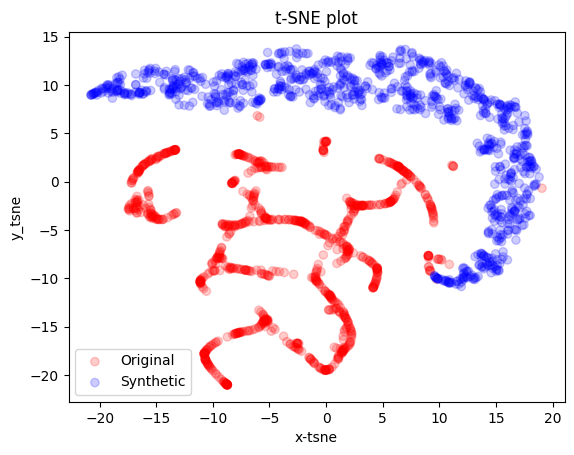

In [31]:
visualization(norm(real_data[:1000, :, :2]), norm(syn_data[:, :, :2]), 'tsne', 'T-sne_', 311)

In [ ]:
dis_score = []
for _ in range(10):
    score = discriminative_score(real_data[:1000],syn_data)
    print(score)
    dis_score.append(score)
np.mean(dis_score)

In [ ]:
# compute cosine similarity
cos_sim = 0
for i in range(c):
        cos_sim += cos_similarity(f_real[i], f_syn[i])

cos_sim /= c
print(cos_sim)

In [28]:
np.save('syn_data.npy',syn_data)

In [ ]:
KDE(real_data,syn_data,185)